# Student Performance Analyzer

This project implements a complete **Student Performance Analyzer** workflow using Python, Pandas, SQLite, Matplotlib, and Seaborn. The workflow is divided into six steps:
1. **Data Generation**: Creating a synthetic dataset of 200 students with custom features using numpy and pandas.
2. **Data Loading and Cleaning**: Verifying statistics, structure, checking for and removing duplicates, and validating data types.
3. **SQL Integration**: Querying data in SQLite using Python's `sqlite3` interface.
4. **Python + Pandas Analysis**: Performing numerical analysis, correlation, and identifying at-risk students.
5. **Visualizations**: Plotting and exporting key statistics as polished PNG charts.
6. **Insights Section**: Generating and printing a final summary report of the findings.


## Step 1 - Data Generation
We generate a synthetic dataset representing 200 students using `numpy.random` functions. To demonstrate the cleaning step (Step 2), we will also intentionally append a few duplicate rows to the dataset.
The generated dataset is then saved as `students.csv` using `pandas`.


In [1]:
# Step 1: Data Generation
import numpy as np
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

# Generate 200 students
n_students = 200
student_ids = np.arange(1001, 1001 + n_students)

# Lists of first and last names to generate realistic name combinations
first_names = ["Liam", "Olivia", "Noah", "Emma", "Oliver", "Ava", "Elijah", "Charlotte", "William", "Sophia",
               "James", "Amelia", "Benjamin", "Isabella", "Lucas", "Mia", "Henry", "Evelyn", "Alexander", "Harper"]
last_names = ["Smith", "Johnson", "Williams", "Brown", "Jones", "Garcia", "Miller", "Davis", "Rodriguez", "Martinez",
              "Hernandez", "Lopez", "Gonzalez", "Wilson", "Anderson", "Thomas", "Taylor", "Moore", "Jackson", "Martin"]

names = [f"{np.random.choice(first_names)} {np.random.choice(last_names)}" for _ in range(n_students)]
ages = np.random.randint(15, 19, size=n_students)
genders = np.random.choice(["Male", "Female"], size=n_students)
attendance = np.random.randint(60, 101, size=n_students)

# Generate scores (using normal distributions clipped between 0 and 100 to make them realistic)
math_scores = np.clip(np.random.normal(65, 18, size=n_students).astype(int), 0, 100)
science_scores = np.clip(np.random.normal(63, 19, size=n_students).astype(int), 0, 100)
english_scores = np.clip(np.random.normal(70, 16, size=n_students).astype(int), 0, 100)
history_scores = np.clip(np.random.normal(68, 17, size=n_students).astype(int), 0, 100)

# Create DataFrame
df = pd.DataFrame({
    'Student_ID': student_ids,
    'Name': names,
    'Age': ages,
    'Gender': genders,
    'Attendance_Percentage': attendance,
    'Math_Score': math_scores,
    'Science_Score': science_scores,
    'English_Score': english_scores,
    'History_Score': history_scores
})

# Calculate Avg_Score
df['Avg_Score'] = df[['Math_Score', 'Science_Score', 'English_Score', 'History_Score']].mean(axis=1)

# Assign Grade
# A (>=85), B (75-84), C (60-74), D (50-59), F (<50)
def assign_grade(score):
    if score >= 85:
        return 'A'
    elif score >= 75:
        return 'B'
    elif score >= 60:
        return 'C'
    elif score >= 50:
        return 'D'
    else:
        return 'F'

df['Grade'] = df['Avg_Score'].apply(assign_grade)

# Assign Pass_Fail
# Pass if Avg_Score >= 50 else Fail
df['Pass_Fail'] = df['Avg_Score'].apply(lambda x: 'Pass' if x >= 50 else 'Fail')

# Intentionally insert duplicate records to test cleaning in Step 2
duplicates = df.iloc[[10, 45, 120]].copy()
df_with_dupes = pd.concat([df, duplicates], ignore_index=True)

# Save to students.csv using pandas
df_with_dupes.to_csv('students.csv', index=False)
print(f"Dataset saved with {len(df_with_dupes)} rows (including duplicates) to 'students.csv'.")


Dataset saved with 203 rows (including duplicates) to 'students.csv'.


## Step 2 - Data Loading and Cleaning
We load the generated `students.csv` file using `pandas`. We then perform basic data validation:
- Check dimensions (shape) and schema information.
- Generate descriptive statistics.
- Scan for and handle missing (null) values.
- Check for duplicates, display them, remove duplicates to ensure data integrity, and verify that the data types are correct.


In [2]:
# Step 2: Data Loading and Cleaning
# Load CSV with pandas
df_loaded = pd.read_csv('students.csv')

# Check shape, info, describe, null values
print("--- Data Shape ---")
print(df_loaded.shape)

print("\n--- Data Info ---")
df_loaded.info()

print("\n--- Descriptive Statistics ---")
print(df_loaded.describe())

print("\n--- Null Values ---")
print(df_loaded.isnull().sum())

# Check for duplicates
duplicate_count = df_loaded.duplicated().sum()
print(f"\n--- Duplicates Found: {duplicate_count} ---")
if duplicate_count > 0:
    print("Duplicate rows:")
    print(df_loaded[df_loaded.duplicated(keep=False)])
    
    # Remove duplicates
    df_cleaned = df_loaded.drop_duplicates().copy()
    print(f"Duplicates removed. Cleaned data shape: {df_cleaned.shape}")
else:
    df_cleaned = df_loaded.copy()

# Verify data types are correct
print("\n--- Verified Data Types ---")
print(df_cleaned.dtypes)


--- Data Shape ---
(203, 12)

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             203 non-null    int64  
 1   Name                   203 non-null    str    
 2   Age                    203 non-null    int64  
 3   Gender                 203 non-null    str    
 4   Attendance_Percentage  203 non-null    int64  
 5   Math_Score             203 non-null    int64  
 6   Science_Score          203 non-null    int64  
 7   English_Score          203 non-null    int64  
 8   History_Score          203 non-null    int64  
 9   Avg_Score              203 non-null    float64
 10  Grade                  203 non-null    str    
 11  Pass_Fail              203 non-null    str    
dtypes: float64(1), int64(7), str(4)
memory usage: 19.2 KB

--- Descriptive Statistics ---
        Student_ID         Age  Attenda

## Step 3 - SQL Integration
We establish a connection to an SQLite database (`student_records.db`) using Python's `sqlite3` library.
The cleaned dataframe is written to a table name `students`, and we write and execute 7 specific SQL queries:
1. Count of pass vs fail students.
2. Average score by gender.
3. Top 10 students by average score.
4. Subject-wise average scores across all students.
5. Count of students in each grade category.
6. Students with attendance below 75 who are still passing.
7. Bottom 10 performers.


In [3]:
# Step 3: SQL Integration
import sqlite3

# Load dataframe into SQLite database using sqlite3
conn = sqlite3.connect('student_records.db')
cursor = conn.cursor()

# Load cleaned dataframe
df_cleaned.to_sql('students', conn, if_exists='replace', index=False)

def run_query(title, query):
    print(f"\n=== {title} ===")
    result_df = pd.read_sql_query(query, conn)
    print(result_df.to_string(index=False))

# 1. Count of pass vs fail students
q1 = """
SELECT Pass_Fail, COUNT(*) as Count
FROM students
GROUP BY Pass_Fail;
"""
run_query("1. Count of pass vs fail students", q1)

# 2. Average score by gender
q2 = """
SELECT Gender, 
       ROUND(AVG(Avg_Score), 2) as Average_Score
FROM students
GROUP BY Gender;
"""
run_query("2. Average score by gender", q2)

# 3. Top 10 students by average score
q3 = """
SELECT Student_ID, Name, Gender, Avg_Score
FROM students
ORDER BY Avg_Score DESC
LIMIT 10;
"""
run_query("3. Top 10 students by average score", q3)

# 4. Subject wise average scores across all students
q4 = """
SELECT ROUND(AVG(Math_Score), 2) as Avg_Math,
       ROUND(AVG(Science_Score), 2) as Avg_Science,
       ROUND(AVG(English_Score), 2) as Avg_English,
       ROUND(AVG(History_Score), 2) as Avg_History
FROM students;
"""
run_query("4. Subject wise average scores across all students", q4)

# 5. Count of students in each grade category
q5 = """
SELECT Grade, COUNT(*) as Count
FROM students
GROUP BY Grade
ORDER BY Grade;
"""
run_query("5. Count of students in each grade category", q5)

# 6. Students with attendance below 75 who are still passing
q6 = """
SELECT Student_ID, Name, Attendance_Percentage, Avg_Score, Pass_Fail
FROM students
WHERE Attendance_Percentage < 75 AND Pass_Fail = 'Pass';
"""
run_query("6. Students with attendance below 75 who are still passing", q6)

# 7. Bottom 10 performers
q7 = """
SELECT Student_ID, Name, Avg_Score, Grade
FROM students
ORDER BY Avg_Score ASC
LIMIT 10;
"""
run_query("7. Bottom 10 performers", q7)



=== 1. Count of pass vs fail students ===
Pass_Fail  Count
     Fail      9
     Pass    191

=== 2. Average score by gender ===
Gender  Average_Score
Female          66.18
  Male          64.83

=== 3. Top 10 students by average score ===
 Student_ID              Name Gender  Avg_Score
       1161      Elijah Brown   Male      87.75
       1003  Charlotte Miller Female      86.00
       1039  Elijah Rodriguez   Male      86.00
       1086      Henry Taylor Female      85.25
       1185     Lucas Johnson   Male      81.25
       1067 Alexander Johnson   Male      81.00
       1085     Oliver Taylor Female      79.00
       1072        Liam Smith   Male      78.50
       1186         Mia Davis   Male      78.50
       1123       Noah Thomas   Male      77.00

=== 4. Subject wise average scores across all students ===
 Avg_Math  Avg_Science  Avg_English  Avg_History
    63.64        61.52        70.14         66.5

=== 5. Count of students in each grade category ===
Grade  Count
    A  

## Step 4 - Python + Pandas Analysis
We perform further calculations and filtering directly using Pandas:
1. Calculate the Pearson correlation coefficient between attendance and average score using `.corr()`.
2. Identify the subject with the lowest class average.
3. Find students at risk: attendance < 75 AND average score < 60.
4. Calculate gender-wise pass percentages.
5. Display grade distributions using `.value_counts()`.


In [4]:
# Step 4: Python + Pandas Analysis
# 1. Correlation between attendance and average score using .corr()
correlation = df_cleaned['Attendance_Percentage'].corr(df_cleaned['Avg_Score'])
print(f"1. Correlation between attendance and average score: {correlation:.4f}")

# 2. Subject with lowest class average
subjects = {
    'Math': df_cleaned['Math_Score'].mean(),
    'Science': df_cleaned['Science_Score'].mean(),
    'English': df_cleaned['English_Score'].mean(),
    'History': df_cleaned['History_Score'].mean()
}
lowest_subject = min(subjects, key=subjects.get)
print(f"\n2. Subject with lowest class average: {lowest_subject} (Avg Score: {subjects[lowest_subject]:.2f})")

# 3. Students at risk: attendance < 75 AND avg_score < 60
at_risk = df_cleaned[(df_cleaned['Attendance_Percentage'] < 75) & (df_cleaned['Avg_Score'] < 60)]
print(f"\n3. Students at risk (attendance < 75 AND average score < 60): {len(at_risk)}")
print(at_risk[['Student_ID', 'Name', 'Attendance_Percentage', 'Avg_Score', 'Grade']].to_string(index=False))

# 4. Gender wise pass percentage
gender_pass = df_cleaned.groupby('Gender')['Pass_Fail'].apply(lambda x: (x == 'Pass').mean() * 100)
print("\n4. Gender-wise pass percentage:")
print(gender_pass.round(2).to_string())

# 5. Grade distribution using value_counts()
grade_counts = df_cleaned['Grade'].value_counts()
print("\n5. Grade distribution using value_counts():")
print(grade_counts.to_string())


1. Correlation between attendance and average score: 0.0177

2. Subject with lowest class average: Science (Avg Score: 61.52)

3. Students at risk (attendance < 75 AND average score < 60): 16
 Student_ID               Name  Attendance_Percentage  Avg_Score Grade
       1002    Lucas Hernandez                     62      58.00     D
       1005        James Brown                     64      56.25     D
       1014    Harper Williams                     61      59.75     D
       1023     Lucas Williams                     74      57.00     D
       1037   William Anderson                     69      49.50     F
       1065        James Brown                     64      59.00     D
       1070      Amelia Martin                     65      45.00     F
       1071       James Miller                     60      57.00     D
       1111      Henry Johnson                     69      49.50     F
       1151    Sophia Williams                     68      56.75     D
       1166 Alexander Ander

## Step 5 - Visualizations
We generate 6 distinct charts using Matplotlib and Seaborn, applying high-quality styling. The figures are saved as PNG files in the local workspace:
1. **Bar chart**: Average score by subject.
2. **Histogram**: Distribution of average scores.
3. **Scatter plot**: Attendance vs. Average Score with Pass/Fail color coding.
4. **Pie chart**: Grade distribution (A/B/C/D/F).
5. **Bar chart**: Pass vs. Fail count by gender.
6. **Heatmap**: Correlation matrix of all numeric columns.


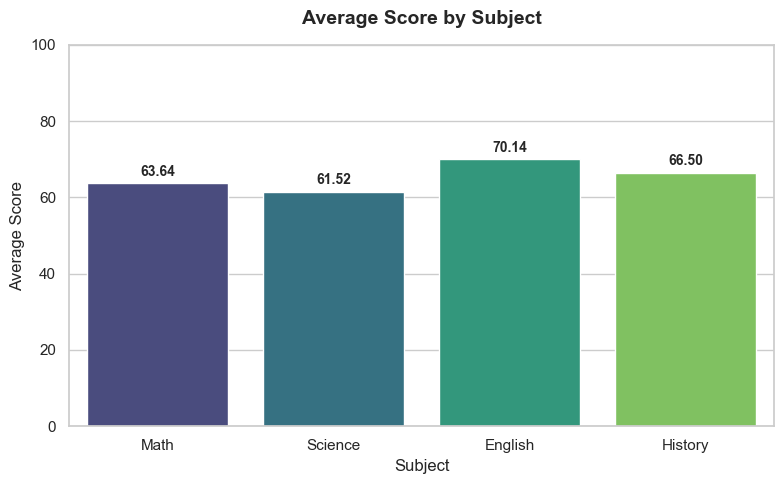

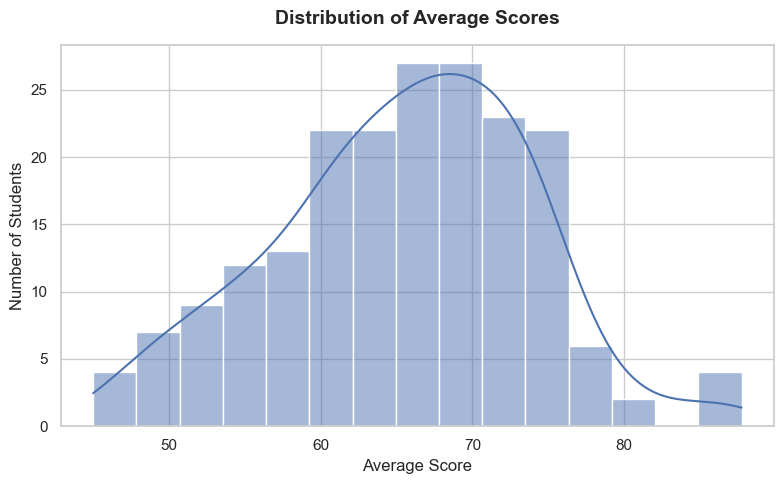

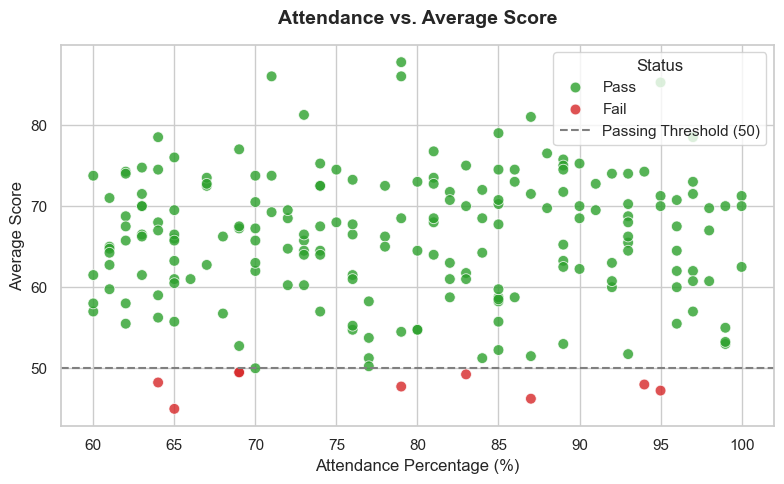

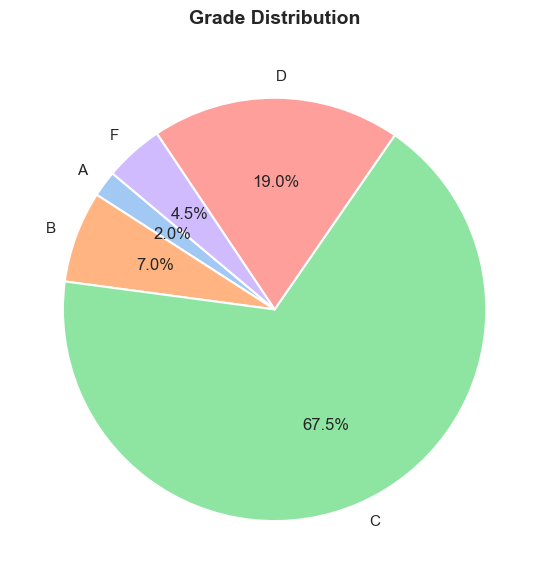

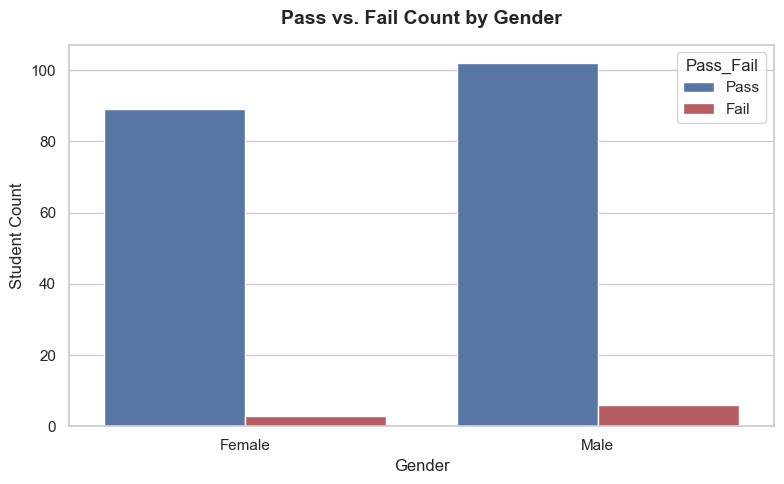

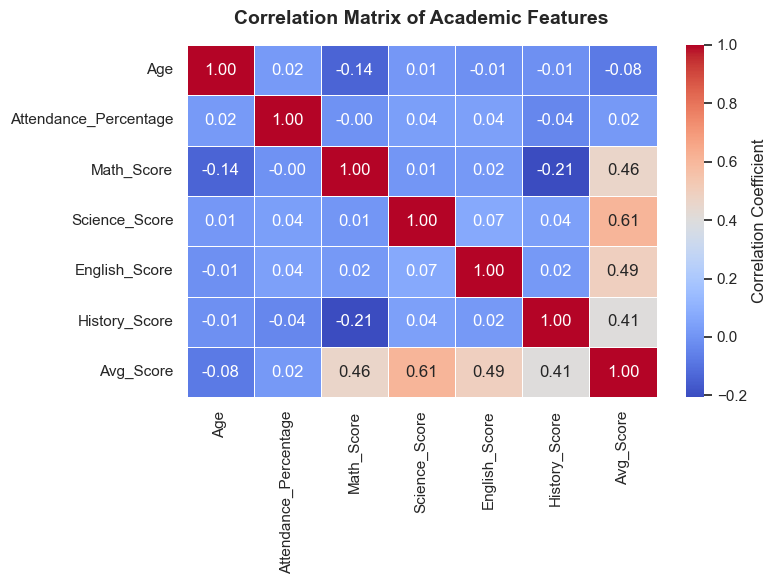

In [5]:
# Step 5: Visualizations using Matplotlib and Seaborn
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Bar chart - Average score by subject
plt.figure(figsize=(8, 5))
subject_names = list(subjects.keys())
subject_values = list(subjects.values())
ax = sns.barplot(x=subject_names, y=subject_values, hue=subject_names, palette="viridis", legend=False)
plt.title("Average Score by Subject", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Subject", fontsize=12)
plt.ylabel("Average Score", fontsize=12)
plt.ylim(0, 100)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 8), 
                textcoords='offset points', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('avg_score_by_subject.png', dpi=150)
plt.show()

# 2. Histogram - Distribution of average scores
plt.figure(figsize=(8, 5))
sns.histplot(df_cleaned['Avg_Score'], bins=15, kde=True, color="#4c72b0")
plt.title("Distribution of Average Scores", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Average Score", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)
plt.tight_layout()
plt.savefig('avg_score_distribution.png', dpi=150)
plt.show()

# 3. Scatter plot - Attendance vs Average Score with Pass/Fail color coding
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_cleaned, x='Attendance_Percentage', y='Avg_Score', 
                hue='Pass_Fail', palette={'Pass': '#2ca02c', 'Fail': '#d62728'}, 
                alpha=0.8, s=60, edgecolor='w')
plt.title("Attendance vs. Average Score", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Attendance Percentage (%)", fontsize=12)
plt.ylabel("Average Score", fontsize=12)
plt.axhline(50, color='gray', linestyle='--', label='Passing Threshold (50)')
plt.legend(title='Status')
plt.tight_layout()
plt.savefig('attendance_vs_avg_score.png', dpi=150)
plt.show()

# 4. Pie chart - Grade distribution (A/B/C/D/F)
plt.figure(figsize=(6, 6))
grade_order = ['A', 'B', 'C', 'D', 'F']
present_grades = [g for g in grade_order if g in grade_counts.index]
counts = [grade_counts[g] for g in present_grades]

colors = sns.color_palette("pastel")[0:len(present_grades)]
plt.pie(counts, labels=present_grades, autopct='%1.1f%%', startangle=140, colors=colors,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
plt.title("Grade Distribution", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('grade_distribution.png', dpi=150)
plt.show()

# 5. Bar chart - Pass vs Fail count by gender
plt.figure(figsize=(8, 5))
sns.countplot(data=df_cleaned, x='Gender', hue='Pass_Fail', palette={'Pass': '#4c72b0', 'Fail': '#c44e52'})
plt.title("Pass vs. Fail Count by Gender", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Student Count", fontsize=12)
plt.tight_layout()
plt.savefig('pass_fail_by_gender.png', dpi=150)
plt.show()

# 6. Heatmap - Correlation matrix of all numeric columns
plt.figure(figsize=(8, 6))
numeric_cols = df_cleaned.select_dtypes(include=[np.number])
# We will include Age, Attendance, Scores, Avg_Score. Let's drop Student_ID for clean visualization as it's an arbitrary index.
numeric_cols_for_corr = numeric_cols.drop(columns=['Student_ID'], errors='ignore')
corr_matrix = numeric_cols_for_corr.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'})
plt.title("Correlation Matrix of Academic Features", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()


## Step 6 - Insights Section
We print a formatted report summarizing the core statistics of the dataset, highlighting the overall pass rate, best/worst subject performance, and the calculated correlation between attendance and average grades.


In [6]:
# Step 6: Insights Section
# Extract metrics
total_students = len(df_cleaned)
pass_count = (df_cleaned['Pass_Fail'] == 'Pass').sum()
pass_percentage = (pass_count / total_students) * 100

top_subject = max(subjects, key=subjects.get)
lowest_subject = min(subjects, key=subjects.get)

num_at_risk = len(at_risk)

# Attendance impact statement based on correlation value
if correlation > 0.5:
    impact_statement = "There is a strong positive correlation between attendance and average score, indicating that students with higher attendance consistently achieve better scores."
elif correlation > 0.2:
    impact_statement = "There is a moderate positive correlation between attendance and average score, suggesting that regular attendance has a positive impact on student scores."
elif correlation > 0:
    impact_statement = "There is a weak positive correlation between attendance and average score, showing a slight tendency for better attendance to relate to higher scores."
else:
    impact_statement = "There is no positive correlation between attendance and average score."

print("==================================================")
print("           STUDENT PERFORMANCE REPORT             ")
print("==================================================")
print(f"Total students analyzed       : {total_students}")
print(f"Overall pass percentage      : {pass_percentage:.2f}%")
print(f"Top performing subject       : {top_subject} (Avg: {subjects[top_subject]:.2f})")
print(f"Lowest performing subject    : {lowest_subject} (Avg: {subjects[lowest_subject]:.2f})")
print(f"Number of at-risk students   : {num_at_risk}")
print("--------------------------------------------------")
print("Attendance Impact:")
print(impact_statement)
print("==================================================")

# Generate HTML Summary Report
html_content = f'''<!DOCTYPE html>
<html>
<head>
    <title>Student Performance Summary Report</title>
    <style>
        body {{
            font-family: "Segoe UI", Tahoma, Geneva, Verdana, sans-serif;
            color: #333;
            max-width: 900px;
            margin: 0 auto;
            padding: 20px;
            background-color: #f8f9fa;
        }}
        h1 {{
            color: #2c3e50;
            border-bottom: 2px solid #34495e;
            padding-bottom: 10px;
            text-align: center;
        }}
        h2 {{
            color: #2980b9;
            margin-top: 30px;
            border-bottom: 1px solid #bdc3c7;
            padding-bottom: 5px;
        }}
        .metrics-grid {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(160px, 1fr));
            gap: 15px;
            margin: 20px 0;
        }}
        .metric-card {{
            background: white;
            padding: 15px;
            border-radius: 8px;
            box-shadow: 0 2px 4px rgba(0,0,0,0.1);
            text-align: center;
            border-top: 4px solid #3498db;
        }}
        .metric-card.at-risk {{
            border-top: 4px solid #e74c3c;
        }}
        .metric-card.pass {{
            border-top: 4px solid #2ecc71;
        }}
        .metric-value {{
            font-size: 22px;
            font-weight: bold;
            color: #2c3e50;
            margin-top: 5px;
        }}
        .metric-label {{
            font-size: 13px;
            color: #7f8c8d;
            font-weight: 500;
        }}
        .statement-box {{
            background: #e8f4f8;
            border-left: 4px solid #3498db;
            padding: 15px;
            border-radius: 4px;
            margin: 15px 0;
            font-style: italic;
        }}
        table {{
            width: 100%;
            border-collapse: collapse;
            margin: 20px 0;
            background: white;
            box-shadow: 0 2px 4px rgba(0,0,0,0.05);
            border-radius: 8px;
            overflow: hidden;
        }}
        th, td {{
            padding: 12px 15px;
            text-align: left;
            border-bottom: 1px solid #e2e8f0;
        }}
        th {{
            background-color: #f1f5f9;
            color: #475569;
            font-weight: 600;
        }}
        tr:hover {{
            background-color: #f8fafc;
        }}
        .charts-grid {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(400px, 1fr));
            gap: 20px;
            margin-top: 20px;
        }}
        .chart-card {{
            background: white;
            padding: 15px;
            border-radius: 8px;
            box-shadow: 0 2px 4px rgba(0,0,0,0.1);
            text-align: center;
        }}
        .chart-card img {{
            max-width: 100%;
            height: auto;
            border-radius: 4px;
        }}
        .footer {{
            text-align: center;
            margin-top: 50px;
            font-size: 12px;
            color: #95a5a6;
            padding-top: 20px;
            border-top: 1px solid #e2e8f0;
        }}
    </style>
</head>
<body>
    <h1>Student Performance Summary Report</h1>
    
    <h2>Key Insights</h2>
    <div class="metrics-grid">
        <div class="metric-card">
            <div class="metric-label">Total Students</div>
            <div class="metric-value">{total_students}</div>
        </div>
        <div class="metric-card pass">
            <div class="metric-label">Overall Pass Percentage</div>
            <div class="metric-value">{pass_percentage:.2f}%</div>
        </div>
        <div class="metric-card">
            <div class="metric-label">Top Subject</div>
            <div class="metric-value">{top_subject} (Avg: {subjects[top_subject]:.2f})</div>
        </div>
        <div class="metric-card">
            <div class="metric-label">Lowest Subject</div>
            <div class="metric-value">{lowest_subject} (Avg: {subjects[lowest_subject]:.2f})</div>
        </div>
        <div class="metric-card at-risk">
            <div class="metric-label">At-Risk Students</div>
            <div class="metric-value">{num_at_risk}</div>
        </div>
    </div>
    
    <div class="statement-box">
        <strong>Attendance Impact Analysis:</strong> {impact_statement}
    </div>
    
    <h2>Descriptive Statistics</h2>
    {df_cleaned.describe().to_html(classes="table")}
    
    <h2>Visualizations</h2>
    <div class="charts-grid">
        <div class="chart-card">
            <h3>Average Score by Subject</h3>
            <img src="avg_score_by_subject.png" alt="Average Score by Subject">
        </div>
        <div class="chart-card">
            <h3>Distribution of Average Scores</h3>
            <img src="avg_score_distribution.png" alt="Distribution of Average Scores">
        </div>
        <div class="chart-card">
            <h3>Attendance vs. Average Score</h3>
            <img src="attendance_vs_avg_score.png" alt="Attendance vs. Average Score">
        </div>
        <div class="chart-card">
            <h3>Grade Distribution</h3>
            <img src="grade_distribution.png" alt="Grade Distribution">
        </div>
        <div class="chart-card">
            <h3>Pass vs. Fail Count by Gender</h3>
            <img src="pass_fail_by_gender.png" alt="Pass vs. Fail Count by Gender">
        </div>
        <div class="chart-card">
            <h3>Correlation Matrix</h3>
            <img src="correlation_matrix.png" alt="Correlation Matrix">
        </div>
    </div>
    
    <div class="footer">
        Generated automatically by Student Performance Analyzer. &copy; 2026
    </div>
</body>
</html>
'''

with open('summary_report.html', 'w', encoding='utf-8') as f:
    f.write(html_content)

print("\nHTML report successfully generated as 'summary_report.html'.")

# Close database connection
conn.close()


           STUDENT PERFORMANCE REPORT             
Total students analyzed       : 200
Overall pass percentage      : 95.50%
Top performing subject       : English (Avg: 70.14)
Lowest performing subject    : Science (Avg: 61.52)
Number of at-risk students   : 16
--------------------------------------------------
Attendance Impact:
There is a weak positive correlation between attendance and average score, showing a slight tendency for better attendance to relate to higher scores.

HTML report successfully generated as 'summary_report.html'.
